# K-Means: alternating minimization and permutation-invariant checks

**Objective.** Cluster standardized Iris and Wine features, inspect convergence,
and compare partitions with scikit-learn without confusing arbitrary cluster IDs with errors.

## Reproducible setup

Install the package from the repository root with `python -m pip install -e ".[dev]"`,
then select a kernel from that environment. Run all cells from top to bottom.
The algorithm is imported from `ml_from_scratch`; this notebook contains only the experiment.
All data are bundled with scikit-learn or generated locally, with seed 42.

## Mathematical intuition

K-Means minimizes the within-cluster squared-distance objective
$$J=\sum_{i=1}^n\|x_i-\mu_{c_i}\|_2^2.$$
With fixed centers, assign each sample to its nearest center. With fixed assignments,
the mean minimizes each cluster's squared distances. Alternating these two steps cannot
increase the objective in ordinary nonempty updates. Initialization still matters because
the joint problem is nonconvex. K-Means++ spreads initial centers, and multiple restarts
select the fit with the lowest final inertia.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans as ReferenceKMeans
from sklearn.datasets import load_iris, load_wine
from sklearn.metrics import adjusted_rand_score

from ml_from_scratch import PCA, KMeans

SEED = 42

## Datasets and fitting

Use whole-dataset z-scores because this is exploratory clustering, not a held-out
generalization estimate. Class labels are withheld from both fits and used only for ARI
evaluation. Both models use three clusters, K-Means++, and ten restarts. The shared seed
does not force identical initial centers across their different random-number generators.

In [2]:
experiments = {}
for name, loader in [("Iris", load_iris), ("Wine", load_wine)]:
    dataset = loader()
    scale = dataset.data.std(axis=0)
    scale = np.where(scale > 0, scale, 1.0)
    X = (dataset.data - dataset.data.mean(axis=0)) / scale
    settings = dict(
        n_clusters=3, init="k-means++", n_init=10, max_iter=300, tol=1e-6, random_state=SEED
    )
    model = KMeans(**settings).fit(X)
    reference = ReferenceKMeans(**settings, algorithm="lloyd").fit(X)
    experiments[name] = (X, dataset.target, model, reference)
    print(
        f"{name}: {X.shape[0]} samples, {X.shape[1]} features, "
        f"{model.n_iter_} updates in selected restart"
    )

Iris: 150 samples, 4 features, 5 updates in selected restart
Wine: 178 samples, 13 features, 2 updates in selected restart


## Independent comparison

ARI is unchanged by a permutation of label IDs and equals one for identical partitions.
Report ARI against known classes and against the reference partition separately. Good
inertia does not guarantee high agreement with class labels, since those labels are not
part of the clustering objective. Different initialization variants or stopping conventions
can legitimately produce different local minima.

In [3]:
for name, (_X, target, model, reference) in experiments.items():
    print(f"{name:4s} inertia: ours={model.inertia_:.6f}, reference={reference.inertia_:.6f}")
    print(
        f"     ARI to classes: ours={adjusted_rand_score(target, model.labels_):.6f}, "
        f"reference={adjusted_rand_score(target, reference.labels_):.6f}"
    )
    print(
        "     ARI between implementations: "
        f"{adjusted_rand_score(model.labels_, reference.labels_):.6f}"
    )

Iris inertia: ours=139.820496, reference=139.820496
     ARI to classes: ours=0.620135, reference=0.620135
     ARI between implementations: 1.000000
Wine inertia: ours=1277.928489, reference=1277.928489
     ARI to classes: ours=0.897495, reference=0.897495
     ARI between implementations: 1.000000


## Visualize a projection and the selected restart's objective

Fit PCA only to display Iris in two dimensions. K-Means itself used all four standardized
features; projected centers are obtained with the same PCA transform as the points.
The trace contains initialization followed by centroid updates from the winning restart.

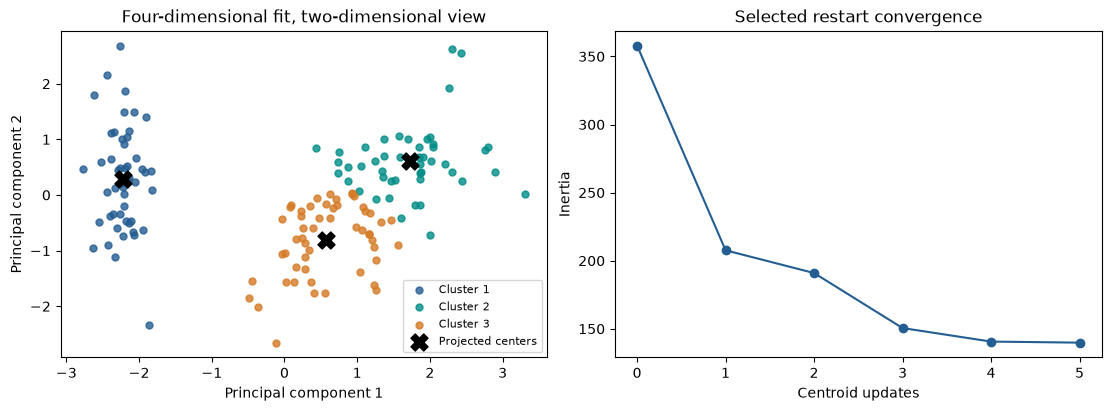

In [4]:
X, target, model, reference = experiments["Iris"]
projection_model = PCA(n_components=2).fit(X)
projection = projection_model.transform(X)
centers = projection_model.transform(model.cluster_centers_)
figure, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for label, color in enumerate(["#245d91", "#008c87", "#d57a25"]):
    points = projection[model.labels_ == label]
    axes[0].scatter(
        points[:, 0], points[:, 1], color=color, alpha=0.8, s=25, label=f"Cluster {label + 1}"
    )
axes[0].scatter(
    centers[:, 0], centers[:, 1], marker="X", s=150, color="black", label="Projected centers"
)
axes[0].set(
    xlabel="Principal component 1",
    ylabel="Principal component 2",
    title="Four-dimensional fit, two-dimensional view",
)
axes[0].legend(fontsize=8)
axes[1].plot(model.inertia_history_, "o-", color="#245d91")
axes[1].set(xlabel="Centroid updates", ylabel="Inertia", title="Selected restart convergence")
plt.show()

## Conclusion

Inertia and partition agreement are the relevant implementation checks; raw cluster IDs
are arbitrary. The fitted centers can assign new samples through `predict` after applying
the same feature scaling. Empty clusters are handled explicitly in the package to avoid
NaNs. When there are fewer distinct observations than requested clusters, not every label
can necessarily be represented.

K-Means assumes squared Euclidean geometry and favors compact clusters. Feature scaling,
outliers, and a chosen cluster count influence its interpretation. See
[the derivation](../docs/mathematics.md) and [comparison assumptions](../docs/benchmarking.md).